## Introduction to Keras

In this notebook, you'll see the basics of building a neural network for classification using the TensorFlow and Keras libraries.

**Important:** Before running any code, click Runtime > Change Runtime Type and select T4 GPU.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## Part 1: Penguins

In [5]:
penguins = pd.read_csv('penguins.csv').dropna().reset_index(drop = True)

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

X = penguins[features]
y = penguins['species']

In order to build our neural network, we need to do a couple of preparation steps.

First, Keras will expect our target variable to be encoded as integers. For this, we can use a LabelEncoder.

Question: After encoding, which species corresponds to a value of 1?

In [6]:
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

Now that our label is encoded, we can perform a train/test split.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 321)

Next, we need to scale our predictors. We'll use a StandardScaler to transform the training and test data.

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Finally, we'll build a model, using the [Sequential model](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) class.

We need the following:
* an [InputLayer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/InputLayer). When you do this, be sure to specify the shape. This should be a tuple whose first element is the number of predictor variables and whose second element is empty.

* a [Dense layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) with 2 neurons which has the hyperbolic tangent activation.

* another Dense layer as an output layer. This output layer should have 3 neurons (since there are 3 possible classes), and needs to have the softmax activation since we want our outputs to be probabilities.

In [10]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(shape=(len(features),)))
model.add(tf.keras.layers.Dense(2, activation='tanh'))
model.add(tf.keras.layers.Dense(3, activation='softmax'))

Now, we can compile our model.

In [11]:
model.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])

You can inspect your model using the summary method.

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

To fit this model, use the `.fit()` method, pass in the target and predictors, and specify the number of epochs (the number of times to go through the entire training dataset).

We'll save the results of model.fit to a variable.

In [13]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.4498 - loss: 0.9961
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4699 - loss: 0.9741  
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4819 - loss: 0.9522 
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.9322 
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5341 - loss: 0.9122 
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5462 - loss: 0.8931 
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5823 - loss: 0.8748 
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6145 - loss: 0.8578 
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6345 - loss: 0.8410 
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6586 - loss: 0.8248 
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6707 - loss: 0.8098 
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6747 - lo

**Generating Predictions:** To get our predictions, you can use the `.predict()` method. Note that this returns probabilities, unlike the predict methods from scikit-learn. Translate these predicted probabilities into predicted classes.

We'll use the numpy [argmax function](https://numpy.org/doc/2.2/reference/generated/numpy.argmax.html) to help with this.

In [14]:
model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step


array([[0.9220972 , 0.04839413, 0.02950862],
       [0.9110989 , 0.05583392, 0.03306723],
       [0.08576623, 0.1612161 , 0.75301766],
       [0.9272351 , 0.04440521, 0.02835966],
       [0.04776038, 0.40514043, 0.5470992 ],
       [0.06256659, 0.42162248, 0.51581097],
       [0.22790985, 0.12622984, 0.6458603 ],
       [0.79997766, 0.15604188, 0.04398048],
       [0.91209817, 0.05646132, 0.0314405 ],
       [0.9273619 , 0.04207327, 0.03056475],
       [0.05908972, 0.16705123, 0.77385914],
       [0.03607352, 0.24114712, 0.7227794 ],
       [0.8513048 , 0.10804798, 0.04064713],
       [0.91183835, 0.05744238, 0.03071922],
       [0.03714119, 0.3813365 , 0.5815223 ],
       [0.0811278 , 0.12005174, 0.7988205 ],
       [0.0866955 , 0.14918335, 0.7641212 ],
       [0.0431035 , 0.21077158, 0.7461249 ],
       [0.9333789 , 0.0396883 , 0.02693289],
       [0.33782053, 0.14150453, 0.52067494],
       [0.8899957 , 0.07237747, 0.03762683],
       [0.82924014, 0.09225596, 0.07850389],
       [0.

In [15]:
np.argmax(model.predict(X_test), axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([0, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0,
       0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0,
       2, 2, 0, 2, 2, 2, 0, 1, 1, 0, 2, 0, 2, 0, 2, 2, 2, 0])

In [16]:
y_pred = np.argmax(model.predict(X_test), axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


Finally, we'll inspect the results using a confusion matrix and classification report.

In [17]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[37  0  0]
 [ 0  4 13]
 [ 0  0 30]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      0.24      0.38        17
           2       0.70      1.00      0.82        30

    accuracy                           0.85        84
   macro avg       0.90      0.75      0.73        84
weighted avg       0.89      0.85      0.81        84



## Part 2: Housing Data

In [18]:
kc_sales = pd.read_csv("./kc_house_data.csv")

X = kc_sales.drop(columns = ['id', 'date', 'price'])
y = kc_sales['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 321)

Now, we'll prep the training and test data.

In [19]:
ct = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), ['zipcode']),
        ('scale', StandardScaler(), [x for x in X_train.columns if x != 'zipcode'])
    ]
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

Now, we'll create a Sequential model which has an InputLayer, three Dense layers with 100 neurons each and relu activation, and one Dense output layer. Since this is a regression problem, the output layer should have one neuron and linear activation.

Then we'll compile this model using the adam optimizer and the mean_squared_error loss.

In [27]:
kc_model = tf.keras.Sequential()
kc_model.add(tf.keras.layers.InputLayer(shape=(X_train.shape[1],)))
kc_model.add(tf.keras.layers.Dense(100, activation='relu'))
kc_model.add(tf.keras.layers.Dense(100, activation='relu'))
kc_model.add(tf.keras.layers.Dense(100, activation='relu'))
kc_model.add(tf.keras.layers.Dense(1))

kc_model.compile('adam', 'mean_squared_error')

It's not always clear how many training epochs we need. One way to choose this is to monitor the model performance on some validation data and to stop training once the performance stops improving on the validation set.

This can be accomplished using the [EarlyStopping callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping).

In [28]:
es = EarlyStopping(monitor='val_loss', patience=2)

Use the fit method on your model. Set the training epochs to 500. Save this to an object named history.

In order to utilize our callback, we need to set a validation split. Use 20% for that. Make sure that you use the EarlyStopping object we just created in the callbacks argument.

For reference, see the [documentation for the fit method](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit).

In [32]:
history = kc_model.fit(X_train, y_train, epochs=500, validation_split=0.2, callbacks=[es])

Epoch 1/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 18052913152.0000 - val_loss: 20031307776.0000
Epoch 2/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17919152128.0000 - val_loss: 19854387200.0000
Epoch 3/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17648928768.0000 - val_loss: 19620769792.0000
Epoch 4/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 17484900352.0000 - val_loss: 19441330176.0000
Epoch 5/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17344675840.0000 - val_loss: 19189469184.0000
Epoch 6/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17139263488.0000 - val_loss: 19062765568.0000
Epoch 7/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16981542912.0000 - val_loss: 19186286592.0000
Epoch 8/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16813104128.0000 - val_loss: 18743656448.0000
Epoch 9/500
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16655171584.0000 - val_loss: 18786252800.0000
Epoch 10/500
406/406 ━━━━━━━━━━━━━━━━

Now, we can plot how the mean squared error improved for both the training and validation data.

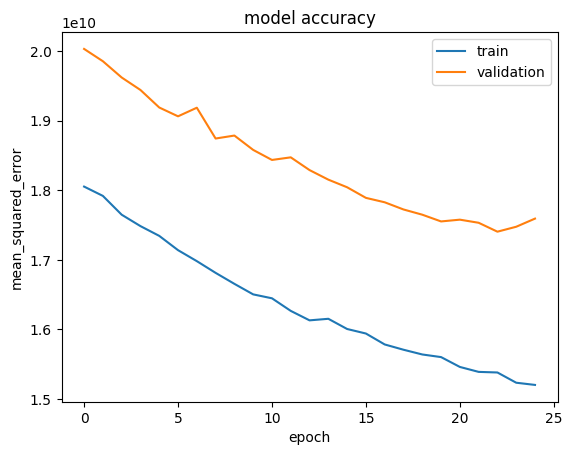

In [33]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'validation')
plt.title('model accuracy')
plt.ylabel('mean_squared_error')
plt.xlabel('epoch')
plt.legend();

Let's see how well the model did on the test data in terms of MSE, RMSE, MAE, MAPE, and R^2?

In [31]:
y_pred = kc_model.predict(X_test)

print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MSE: 19313601920.99158
RMSE: 138973.38565708033
MAE: 78899.1941067959
MAPE: 0.15432972995732558
R2: 0.8539671115104789
